# Phase 1 Verification - Data Infrastructure

Confirms all three spread series are correctly constructed and stored in Postgres.
Visual inspection for roll artefacts (false jumps at contract expiry).

**Pre-requisites before running:**
1. `docker compose up -d` - Postgres must be running
2. `.env` populated with DB credentials and DATABENTO_API_KEY
3. `uv sync` - install all deps, create .venv (only needed one time)
4. `uv run alembic upgrade head` - tables created
5. `uv run python -m data.roll_calendar` - roll calendar seeded
6. `uv run python -m data.ingest` - OHLCV data pulled (takes ~5 min first run)
7. `uv run python -m data.build_spreads` - spread series constructed

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from db.session import get_session
from db.models import Spread, RollCalendarEntry
from data.roll_calendar import generate_roll_calendar

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (16, 5)

In [45]:
def load_spread(name: str) -> pd.DataFrame:
    session = get_session()
    rows = session.query(Spread).filter_by(spread_name=name).order_by(Spread.date).all()
    session.close()
    return pd.DataFrame([
        {'date': r.date, 'value': r.value, 'roll_window': r.roll_window_flag, 'regime': r.regime}
        for r in rows
    ]).set_index('date')


def load_roll_dates(product: str) -> list:
    session = get_session()
    rows = session.query(RollCalendarEntry).filter_by(product=product).all()
    session.close()
    return [r.expiry for r in rows]


def plot_spread(name: str, product: str, title: str):
    df = load_spread(name)
    roll_dates = load_roll_dates(product)

    fig, ax = plt.subplots()
    ax.plot(df.index, df['value'], linewidth=0.8, color='#00b4d8', label='Spread')

    # Shade roll windows
    in_window = df['roll_window'].astype(bool)
    prev = False
    start = None
    for d, val in in_window.items():
        if val and not prev:
            start = d
        elif not val and prev and start:
            ax.axvspan(start, d, alpha=0.15, color='orange', label='Roll window' if start == in_window[in_window].index[0] else '')
        prev = val

    ax.axhline(0, color='white', linewidth=0.4, linestyle='--')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Spread ($/bbl)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'{name}: {len(df)} rows | roll_window rows: {in_window.sum()} | nulls: {df["value"].isna().sum()}')

## 1. WTI Calendar Spread (M1 – M2)

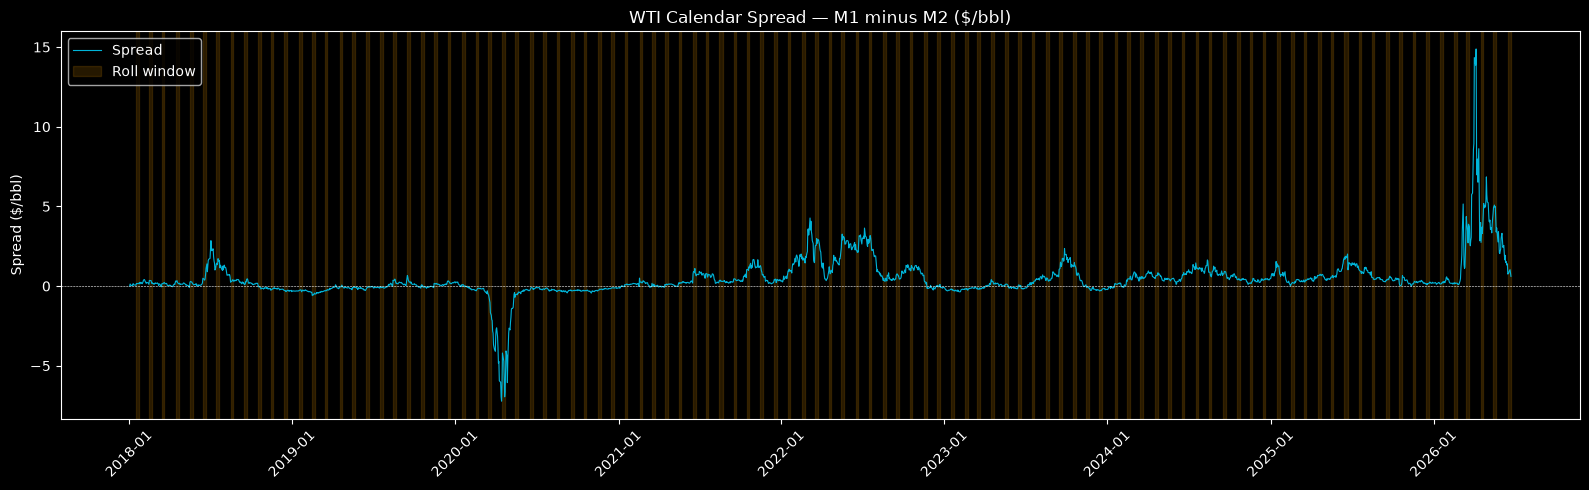

wti_calendar: 2636 rows | roll_window rows: 522 | nulls: 0


In [46]:
plot_spread('wti_calendar', 'CL', 'WTI Calendar Spread - M1 minus M2 ($/bbl)')

**Visual inspection notes:**
- [ ] No unexplained discontinuities at roll dates
- [ ] Contango (negative) vs backwardation (positive) periods look economically sensible
- [x] 2020 COVID contango visible - spread reached ~-$7 (June–July 2020 deep contango). Note: the famous May 2020 negative price (-$37) is **not** captured here because the roll calendar already rolled to June as M1 five days before the May expiry.
- [x] 2022 Russia-Ukraine backwardation spike visible (~$3–4)

### 1a. Zoomed Views - Spike Periods

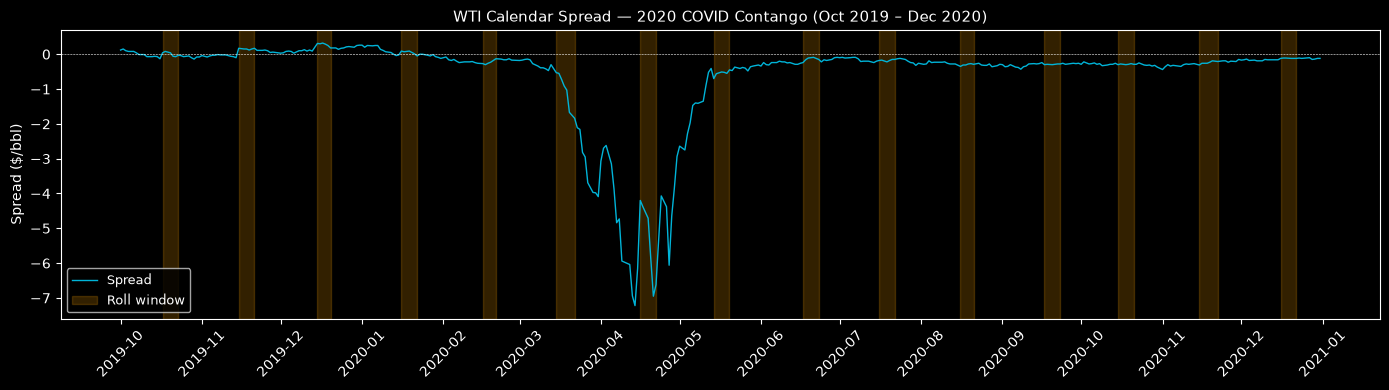

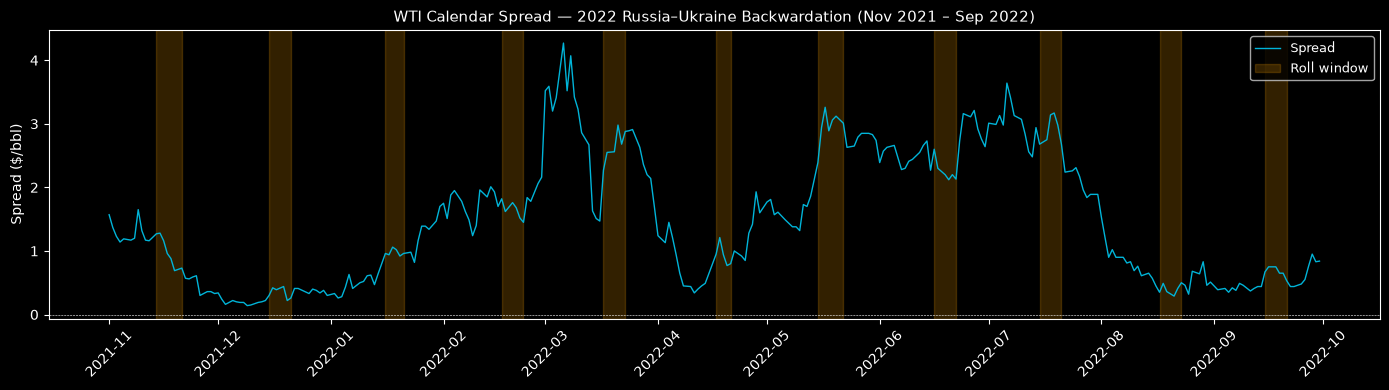

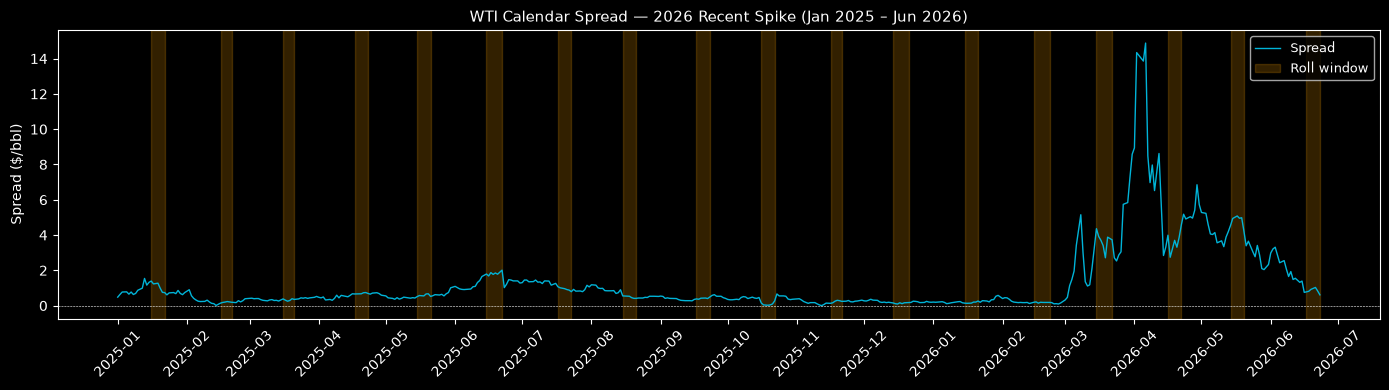

In [50]:
from datetime import date as _date

def plot_spread_zoomed(name: str, product: str, title: str, date_from: str, date_to: str):
    df = load_spread(name)
    d0 = _date.fromisoformat(date_from)
    d1 = _date.fromisoformat(date_to)
    df = df[(df.index >= d0) & (df.index <= d1)]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df.index, df['value'], linewidth=1.0, color='#00b4d8', label='Spread')

    # Shade roll windows
    in_window = df['roll_window'].astype(bool)
    prev = False
    start = None
    first_window = in_window[in_window].index[0] if in_window.any() else None
    for d, val in in_window.items():
        if val and not prev:
            start = d
        elif not val and prev and start:
            ax.axvspan(start, d, alpha=0.2, color='orange', label='Roll window' if start == first_window else '')
        prev = val

    ax.axhline(0, color='white', linewidth=0.4, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Spread ($/bbl)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# 2020 - COVID demand collapse → deep contango (Jun–Jul 2020)
plot_spread_zoomed(
    'wti_calendar', 'CL',
    'WTI Calendar Spread - 2020 COVID Contango (Oct 2019 – Dec 2020)',
    '2019-10-01', '2020-12-31',
)

# 2022 - Russia–Ukraine invasion → sharp backwardation spike (Feb–Apr 2022)
plot_spread_zoomed(
    'wti_calendar', 'CL',
    'WTI Calendar Spread - 2022 Russia–Ukraine Backwardation (Nov 2021 – Sep 2022)',
    '2021-11-01', '2022-09-30',
)

# 2026 - recent spike (context window: Jan 2025 – present)
plot_spread_zoomed(
    'wti_calendar', 'CL',
    'WTI Calendar Spread - 2026 Recent Spike (Jan 2025 – Jun 2026)',
    '2025-01-01', '2026-06-23',
)


## 2. Brent Calendar Spread (M1 – M2)

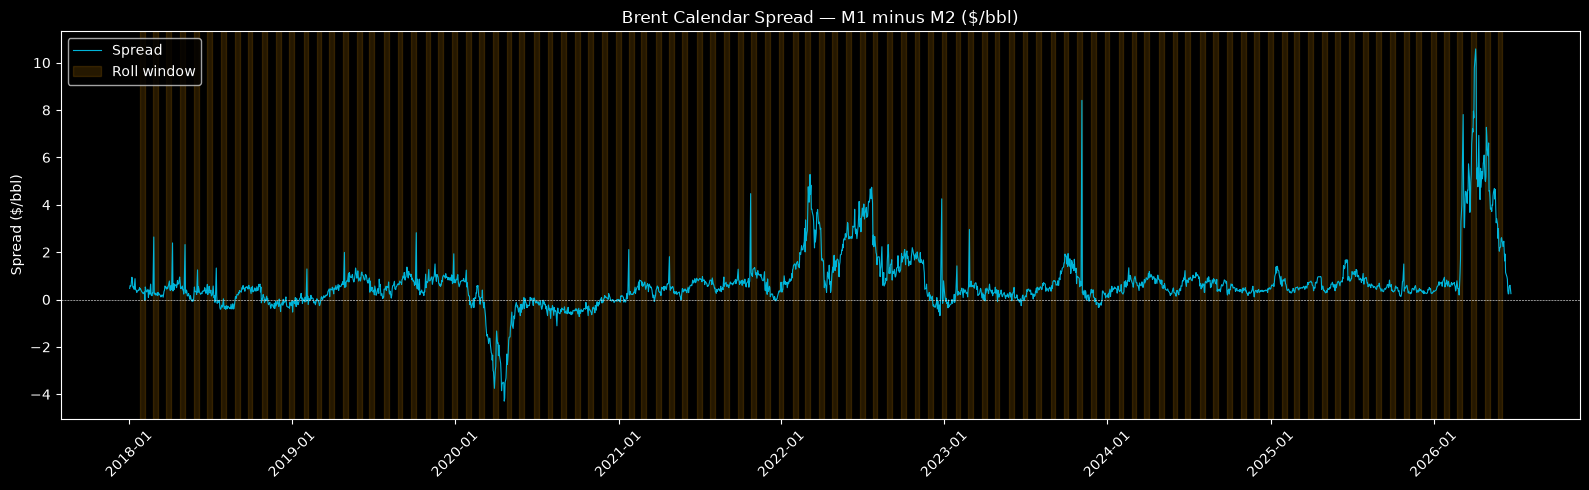

brent_calendar: 2606 rows | roll_window rows: 921 | nulls: 0


In [34]:
plot_spread('brent_calendar', 'BZ', 'Brent Calendar Spread - M1 minus M2 ($/bbl)')

**Visual inspection notes:**
- [ ] No unexplained discontinuities at roll dates
- [ ] Similar contango/backwardation pattern to WTI (correlated but not identical)
- [ ] No negative prices during April 2020 (Brent did not go negative unlike WTI)

## 3. Brent–WTI Cross-Market Spread

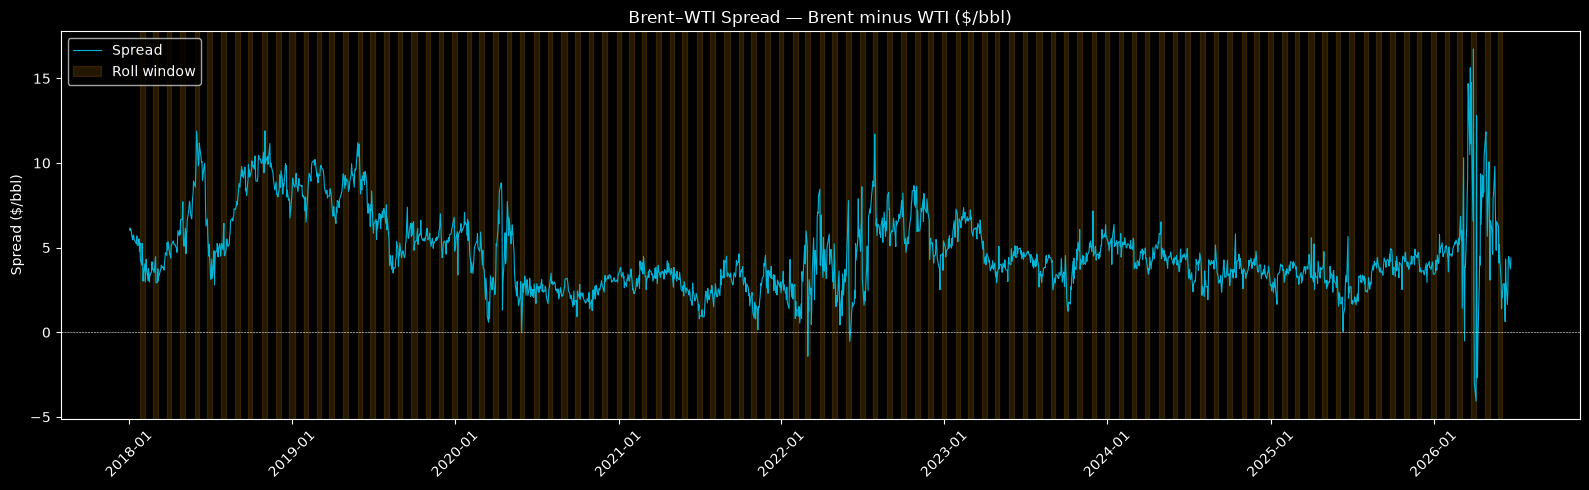

brent_wti: 2131 rows | roll_window rows: 721 | nulls: 0


In [28]:
plot_spread('brent_wti', 'BZ', 'Brent–WTI Spread - Brent minus WTI ($/bbl)')

**Visual inspection notes:**

*Data covers 2018-01-02 onwards - the two pre-2018 structural breaks are not observable in this dataset.*

- [ ] Structural break ~2011 (Cushing glut, spread widened to ~$25): **NOT VISIBLE** - predates data start
- [ ] Structural break ~2015 (US crude export ban repeal, spread narrowed sharply): **NOT VISIBLE** - predates data start
- [x] Mid-2018 spike to ~$10–11 visible - Permian Basin pipeline takeaway constraints caused WTI/Cushing to trade at an unusually wide discount to seaborne Brent
- [x] 2020 COVID compression visible - both crudes fell together, spread briefly near zero
- [x] 2022 Russia-Ukraine widening visible - seaborne Brent at a premium as sanctions disrupted Russian crude flows
- [x] 2018–2026 spread broadly $2–8, mostly positive (Brent premium), consistent with post-export-ban mean-reversion regime

## 4. DB Row Counts - Sanity Check

In [35]:
from db.models import Contract, OHLCVBar

session = get_session()
print(f"contracts table: {session.query(Contract).count()} rows")
print(f"ohlcv_bars table: {session.query(OHLCVBar).count()} rows")
print(f"spreads table: {session.query(Spread).count()} rows")
print(f"roll_calendar table: {session.query(RollCalendarEntry).count()} rows")
session.close()

contracts table: 279 rows
ohlcv_bars table: 79414 rows
spreads table: 7373 rows
roll_calendar table: 324 rows


In [36]:
# Date range check - should be 2018-01-01 to today
for name in ['wti_calendar', 'brent_calendar', 'brent_wti']:
    df = load_spread(name)
    if not df.empty:
        print(f"{name}: {df.index.min()} → {df.index.max()} ({len(df)} rows)")
    else:
        print(f"{name}: EMPTY - ingest may not have run yet")

wti_calendar: 2018-01-02 → 2026-06-23 (2636 rows)
brent_calendar: 2018-01-02 → 2026-06-23 (2606 rows)
brent_wti: 2018-01-02 → 2026-06-23 (2131 rows)
